# Güçlendirilmiş Klasik LSTM Modeli

Bu notebook, son oluşturulan güçlü CNN/MLP modeliyle adil karşılaştırma yapılabilmesi için LSTM modelini aynı deneysel akışa göre düzenler:

- EfficientNet-B0 özellik çıkarımı
- StandardScaler
- PCA(256)
- PCA sonrası StandardScaler
- 16×16 LSTM giriş dizisi
- 5 katlı Stratified K-Fold hiperparametre araması
- Macro-F1'e göre en iyi konfigürasyon seçimi
- Sınıf bazlı doğru / yanlış tahmin tablosu


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.6 MB/s eta 0:00:00
Kullanılan cihaz: cpu
Sınıf eşlemesi: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}

Kayıtlı train/test ayrımı yükleniyor.

Sınıf bazlı toplam görüntü sayısı:


,Sınıf,Görüntü sayısı
0,glioma_tumor,926
1,meningioma_tumor,937
2,no_tumor,500
3,pituitary_tumor,901



Eğitim görüntü sayısı: 2609
Test görüntü sayısı   : 655
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 124MB/s]



Feature extractor: EfficientNet-B0
Ham özellik boyutu: 1280

Kayıtlı EfficientNet-B0 özellikleri yükleniyor:
/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_classical_cnn_strong_mlp/efficientnet_b0_features_seed42_img224.npz

Ham özellik şekilleri:
X_train_raw: (2609, 1280)
X_test_raw : (655, 1280)

PCA sonrası özellik şekilleri:
X_train_features: (2609, 256)
X_test_features : (655, 256)
PCA açıklanan varyans: 0.8574

5 KATLI STRATIFIED K-FOLD HİPERPARAMETRE ARAMA BAŞLIYOR

--- Konfigürasyon: lstm_h64_l1_do030_lr1e-3 ---
Fold 1/5 | Best Val Macro-F1: 0.7656 | Best Epoch: 42
Fold 2/5 | Best Val Macro-F1: 0.7732 | Best Epoch: 43
Fold 3/5 | Best Val Macro-F1: 0.7678 | Best Epoch: 44
Fold 4/5 | Best Val Macro-F1: 0.7344 | Best Epoch: 44
Fold 5/5 | Best Val Macro-F1: 0.7531 | Best Epoch: 42

--- Konfigürasyon: lstm_h96_l1_do030_lr7e-4 ---
Fold 1/5 | Best Val Macro-F1: 0.7911 | Best Epoch: 44
Fold 2/5 | Best Val Macro-F1: 0.7831 | Best Epoch: 43
Fold 3/5 | Best Val Macro-F1: 0.7981 | B

...

,Dosya yolu,Dosya adı,Gerçek sınıf,Tahmin edilen sınıf,Sonuç,Tahmin güveni,Gerçek sınıf olasılığı,Tahmin edilen sınıf olasılığı
0,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,gg (272).jpg,glioma_tumor,glioma_tumor,Doğru,0.9851,0.9851,0.9851
1,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,m1(57).jpg,meningioma_tumor,meningioma_tumor,Doğru,0.5016,0.5016,0.5016
2,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,gg (374).jpg,glioma_tumor,glioma_tumor,Doğru,0.9808,0.9808,0.9808
3,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,T105.jpg,no_tumor,no_tumor,Doğru,0.9681,0.9681,0.9681
4,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,gg (321).jpg,glioma_tumor,glioma_tumor,Doğru,0.9755,0.9755,0.9755
...,...,...,...,...,...,...,...,...
650,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,image(27).jpg,glioma_tumor,glioma_tumor,Doğru,0.9444,0.9444,0.9444
651,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,m3 (155).jpg,meningioma_tumor,meningioma_tumor,Doğru,0.9831,0.9831,0.9831
652,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,m (186).jpg,meningioma_tumor,glioma_tumor,Yanlış,0.5915,0.2297,0.5915
653,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,gg (492).jpg,glioma_tumor,glioma_tumor,Doğru,0.9717,0.9717,0.9717



Görüntü bazlı detaylı test sonuçları kaydedildi:
/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_classical_lstm_strong_fair/test_goruntu_bazli_sonuclar.csv

SADECE YANLIŞ TAHMİN EDİLEN TEST GÖRÜNTÜLERİ


,Dosya yolu,Dosya adı,Gerçek sınıf,Tahmin edilen sınıf,Sonuç,Tahmin güveni,Gerçek sınıf olasılığı,Tahmin edilen sınıf olasılığı
16,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,m (80).jpg,meningioma_tumor,glioma_tumor,Yanlış,0.7945,0.1928,0.7945
18,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,image(193).jpg,no_tumor,meningioma_tumor,Yanlış,0.5209,0.2152,0.5209
28,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,m2 (77).jpg,meningioma_tumor,glioma_tumor,Yanlış,0.7868,0.1805,0.7868
31,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,image(33).jpg,glioma_tumor,pituitary_tumor,Yanlış,0.7858,0.0254,0.7858
41,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,m1(36).jpg,meningioma_tumor,glioma_tumor,Yanlış,0.5142,0.3139,0.5142
...,...,...,...,...,...,...,...,...
598,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,image(64).jpg,no_tumor,meningioma_tumor,Yanlış,0.4214,0.3314,0.4214
600,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,image(133).jpg,no_tumor,meningioma_tumor,Yanlış,0.8966,0.0550,0.8966
637,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,gg (38).jpg,glioma_tumor,no_tumor,Yanlış,0.5835,0.4069,0.5835
647,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,m1(73).jpg,meningioma_tumor,glioma_tumor,Yanlış,0.6511,0.3212,0.6511



CLASSIFICATION REPORT
                  precision    recall  f1-score   support

    glioma_tumor     0.8956    0.8763    0.8859       186
meningioma_tumor     0.8466    0.8511    0.8488       188
        no_tumor     0.9368    0.8900    0.9128       100
 pituitary_tumor     0.9206    0.9613    0.9405       181

        accuracy                         0.8947       655
       macro avg     0.8999    0.8947    0.8970       655
    weighted avg     0.8947    0.8947    0.8945       655



<Figure size 800x600 with 0 Axes>

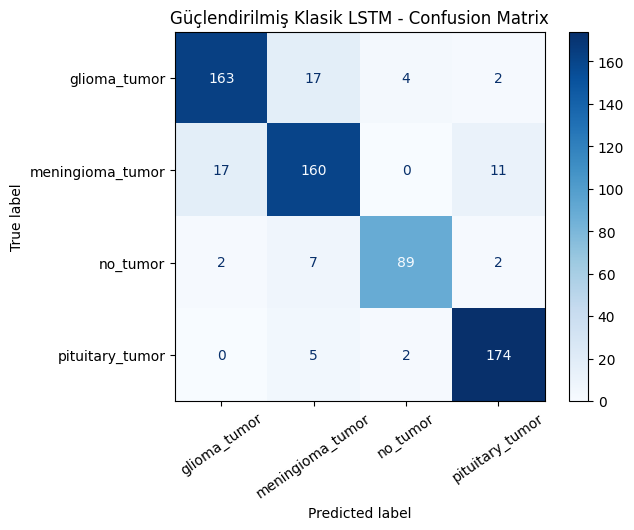

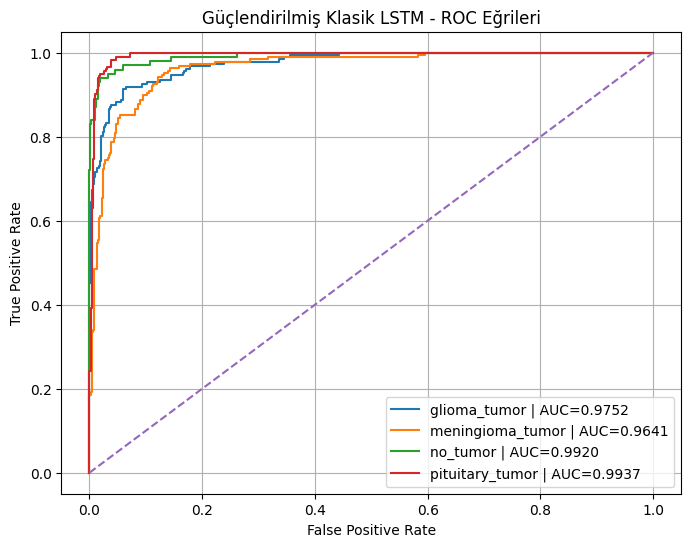


MAKALE / SLAYT İÇİN KISA ÖZET

Güçlendirilmiş klasik LSTM modelinde, MR görüntülerinden önceden eğitilmiş
EfficientNet-B0 modeli ile 1280 boyutlu derin öznitelikler çıkarılmıştır.
Bu öznitelikler önce standartlaştırılmış, ardından PCA ile 256 boyuta
indirgenmiş ve PCA sonrası tekrar standartlaştırılmıştır. Sınıflandırma aşamasında,
256 boyutlu PCA vektörü 16x16 diziye dönüştürülerek LSTM tabanlı
sınıflandırıcıya verilmiştir. Hiperparametreler 5 katlı Stratified K-Fold
doğrulama ile Macro-F1 ölçütüne göre seçilmiştir.

Test kümesindeki toplam 655 görüntünün 586 tanesi doğru,
69 tanesi yanlış sınıflandırılmıştır. Modelin genel test doğruluğu
0.8947, Macro-F1 değeri 0.8970 olarak elde edilmiştir.



In [1]:
# ============================================================
# GÜÇLENDİRİLMİŞ KLASİK LSTM KARŞILAŞTIRMA MODELİ
# Adil karşılaştırma için CNN/MLP modeliyle aynı ön işleme ve arama akışı kullanılır.
# SVM'deki güçlü deneysel akışa benzer biçimde:
# EfficientNet-B0 özellik çıkarımı + StandardScaler + PCA(256)
# + PCA sonrası StandardScaler + 5 katlı StratifiedKFold ile
# hiperparametre seçimi + LSTM tabanlı sınıflandırıcı kullanılır.
#
# Not: Bu model klasik / hibrit olmayan bir modeldir; kuantum katman içermez.
# Test verilerinde sınıf bazlı doğru / yanlış tahmin tablosu dahil.
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

# ============================================================
# 1) KURULUMLAR
# ============================================================
!pip -q install --upgrade pip
!pip -q install torchvision scikit-learn pandas tqdm matplotlib joblib openpyxl

# ============================================================
# 2) IMPORTLAR
# ============================================================
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

import torchvision.transforms as T
import torchvision.models as models

import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# 3) GENEL AYARLAR
# ============================================================
SEED = 42


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Kullanılan cihaz:", DEVICE)

# Burayı kendi veri klasörüne göre kontrol et
DATA_ROOT = "/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/Data"

CLASS_NAMES = [
    "glioma_tumor",
    "meningioma_tumor",
    "no_tumor",
    "pituitary_tumor"
]

CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: cls for cls, i in CLASS_TO_IDX.items()}
N_CLASSES = len(CLASS_NAMES)

CLASS_DIRS = {cls: os.path.join(DATA_ROOT, cls) for cls in CLASS_NAMES}

IMG_SIZE = 224
TEST_SIZE = 0.20

FEATURE_BATCH_SIZE = 64
PCA_COMPONENTS = 256
SEQ_LEN = 16
INPUT_SIZE = 16
assert PCA_COMPONENTS == SEQ_LEN * INPUT_SIZE

# SVM/CNN'deki güçlü yapı ile benzer biçimde LSTM hiperparametre araması yapılır.
N_FOLDS = 5
SEARCH_MAX_EPOCHS = 45
SEARCH_PATIENCE = 7
FINAL_MIN_EPOCHS = 8

FORCE_REEXTRACT_IMAGE_FEATURES = False

CACHE_DIR = "/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_classical_lstm_strong_fair"
os.makedirs(CACHE_DIR, exist_ok=True)

# Son oluşturulan güçlü CNN/MLP modeliyle birebir aynı train/test ayrımı ve özellik cache'i
# varsa onu kullanır. Böylece karşılaştırma daha adil olur.
REFERENCE_CNN_CACHE_DIR = "/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_classical_cnn_strong_mlp"
REFERENCE_FEATURE_CACHE_PATH = os.path.join(
    REFERENCE_CNN_CACHE_DIR,
    f"efficientnet_b0_features_seed{SEED}_img{IMG_SIZE}.npz"
)
REFERENCE_TRAIN_SPLIT_PATH = os.path.join(REFERENCE_CNN_CACHE_DIR, "train_split.csv")
REFERENCE_TEST_SPLIT_PATH = os.path.join(REFERENCE_CNN_CACHE_DIR, "test_split.csv")

LOCAL_FEATURE_CACHE_PATH = os.path.join(CACHE_DIR, f"efficientnet_b0_features_seed{SEED}_img{IMG_SIZE}.npz")
LOCAL_TRAIN_SPLIT_PATH = os.path.join(CACHE_DIR, "train_split.csv")
LOCAL_TEST_SPLIT_PATH = os.path.join(CACHE_DIR, "test_split.csv")

FEATURE_CACHE_PATH = REFERENCE_FEATURE_CACHE_PATH if os.path.exists(REFERENCE_FEATURE_CACHE_PATH) else LOCAL_FEATURE_CACHE_PATH
TRAIN_SPLIT_PATH = REFERENCE_TRAIN_SPLIT_PATH if os.path.exists(REFERENCE_TRAIN_SPLIT_PATH) else LOCAL_TRAIN_SPLIT_PATH
TEST_SPLIT_PATH = REFERENCE_TEST_SPLIT_PATH if os.path.exists(REFERENCE_TEST_SPLIT_PATH) else LOCAL_TEST_SPLIT_PATH

MODEL_SAVE_PATH = os.path.join(CACHE_DIR, "strong_classical_lstm_model.pt")
SCALER_PCA_SAVE_PATH = os.path.join(CACHE_DIR, "lstm_scaler_pca_post_scaler.joblib")
SEARCH_RESULTS_PATH = os.path.join(CACHE_DIR, "lstm_hyperparametre_arama_sonuclari.csv")
DETAIL_TEST_RESULTS_PATH = os.path.join(CACHE_DIR, "test_goruntu_bazli_sonuclar.csv")
CLASS_SUMMARY_PATH = os.path.join(CACHE_DIR, "sinif_bazli_dogru_yanlis_sonuclar.csv")
CONFUSION_DETAIL_PATH = os.path.join(CACHE_DIR, "siniflar_arasi_karisiklik_tablosu.csv")

print("Sınıf eşlemesi:", CLASS_TO_IDX)

# ============================================================
# 4) VERİLERİ LİSTELEME VE 80/20 BÖLME
# ============================================================
def list_images(folder):
    exts = (".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff")
    files = []

    if not os.path.isdir(folder):
        print("UYARI: Klasör bulunamadı:", folder)
        return files

    for root, _, names in os.walk(folder):
        for name in names:
            if name.lower().endswith(exts):
                files.append(os.path.join(root, name))

    return sorted(files)


def build_classwise_split(class_dirs, class_names, test_size=0.2, seed=42):
    """İlk CNN dosyasındakiyle aynı mantıkta sınıf bazlı 80/20 ayrım yapar."""
    train_items = []
    test_items = []
    class_counts = {}

    for cls in class_names:
        files = list_images(class_dirs[cls])
        class_counts[cls] = len(files)

        if len(files) == 0:
            raise ValueError(f"Bu sınıf için görüntü bulunamadı: {cls}")

        y = CLASS_TO_IDX[cls]

        tr, te = train_test_split(
            files,
            test_size=test_size,
            random_state=seed,
            shuffle=True
        )

        train_items.extend([(p, y, cls) for p in tr])
        test_items.extend([(p, y, cls) for p in te])

    rng = np.random.default_rng(seed)
    rng.shuffle(train_items)
    rng.shuffle(test_items)

    return train_items, test_items, class_counts


def save_split_csv(items, path):
    df = pd.DataFrame(items, columns=["path", "label", "class_name"])
    df.to_csv(path, index=False)


def load_split_csv(path):
    df = pd.read_csv(path)
    return [
        (str(row["path"]), int(row["label"]), str(row["class_name"]))
        for _, row in df.iterrows()
    ]


if os.path.exists(TRAIN_SPLIT_PATH) and os.path.exists(TEST_SPLIT_PATH):
    print("\nKayıtlı train/test ayrımı yükleniyor.")
    train_items = load_split_csv(TRAIN_SPLIT_PATH)
    test_items = load_split_csv(TEST_SPLIT_PATH)

    class_counts = {
        cls: len(list_images(CLASS_DIRS[cls]))
        for cls in CLASS_NAMES
    }
else:
    train_items, test_items, class_counts = build_classwise_split(
        CLASS_DIRS,
        CLASS_NAMES,
        test_size=TEST_SIZE,
        seed=SEED
    )

    save_split_csv(train_items, TRAIN_SPLIT_PATH)
    save_split_csv(test_items, TEST_SPLIT_PATH)

print("\nSınıf bazlı toplam görüntü sayısı:")
display(pd.DataFrame([
    {"Sınıf": cls, "Görüntü sayısı": class_counts[cls]}
    for cls in CLASS_NAMES
]))

print(f"\nEğitim görüntü sayısı: {len(train_items)}")
print(f"Test görüntü sayısı   : {len(test_items)}")

# ============================================================
# 5) EFFICIENTNET-B0 İLE DERİN ÖZNİTELİK ÇIKARIMI
# ============================================================
weights = models.EfficientNet_B0_Weights.DEFAULT
feature_transform = weights.transforms()


class ImagePathDataset(Dataset):
    def __init__(self, items, transform):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, y, cls_name = self.items[idx]
        img = Image.open(path).convert("RGB")
        img = self.transform(img)
        return img, y


def build_efficientnet_b0_feature_extractor():
    model = models.efficientnet_b0(weights=weights)
    model.classifier = nn.Identity()  # 1280 boyutlu özellik vektörü üretir.
    model = model.to(DEVICE)
    model.eval()

    for p in model.parameters():
        p.requires_grad = False

    return model


feature_extractor = build_efficientnet_b0_feature_extractor()
print("\nFeature extractor: EfficientNet-B0")
print("Ham özellik boyutu: 1280")


@torch.no_grad()
def extract_features(items, split_name):
    dataset = ImagePathDataset(items, feature_transform)
    loader = DataLoader(
        dataset,
        batch_size=FEATURE_BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=(DEVICE.type == "cuda")
    )

    features = []
    labels_out = []

    for x, y in tqdm(loader, desc=f"{split_name} özellikleri çıkarılıyor"):
        x = x.to(DEVICE, non_blocking=True)
        f = feature_extractor(x)
        features.append(f.detach().cpu().numpy().astype(np.float32))
        labels_out.append(np.asarray(y, dtype=np.int64))

    X = np.concatenate(features, axis=0)
    y = np.concatenate(labels_out, axis=0)
    return X, y


if os.path.exists(FEATURE_CACHE_PATH) and not FORCE_REEXTRACT_IMAGE_FEATURES:
    print("\nKayıtlı EfficientNet-B0 özellikleri yükleniyor:")
    print(FEATURE_CACHE_PATH)
    data = np.load(FEATURE_CACHE_PATH)
    X_train_raw = data["X_train_raw"]
    y_train = data["y_train"]
    X_test_raw = data["X_test_raw"]
    y_test = data["y_test"]
else:
    X_train_raw, y_train = extract_features(train_items, "Eğitim")
    X_test_raw, y_test = extract_features(test_items, "Test")

    np.savez_compressed(
        FEATURE_CACHE_PATH,
        X_train_raw=X_train_raw,
        y_train=y_train,
        X_test_raw=X_test_raw,
        y_test=y_test
    )
    print("\nÖzellikler kaydedildi:")
    print(FEATURE_CACHE_PATH)

print("\nHam özellik şekilleri:")
print("X_train_raw:", X_train_raw.shape)
print("X_test_raw :", X_test_raw.shape)

# ============================================================
# 6) STANDARD SCALER + PCA + PCA SONRASI SCALER
# ============================================================
# Güçlü SVM modelindeki mantığa benzer biçimde, PCA'dan önce ve sonra ölçekleme yapılır.
raw_scaler = StandardScaler()
X_train_scaled = raw_scaler.fit_transform(X_train_raw).astype(np.float32)
X_test_scaled = raw_scaler.transform(X_test_raw).astype(np.float32)

pca_dim = min(PCA_COMPONENTS, X_train_scaled.shape[0] - 1, X_train_scaled.shape[1])

pca = PCA(n_components=pca_dim, random_state=SEED, svd_solver="randomized")
X_train_pca = pca.fit_transform(X_train_scaled).astype(np.float32)
X_test_pca = pca.transform(X_test_scaled).astype(np.float32)

post_pca_scaler = StandardScaler()
X_train_features = post_pca_scaler.fit_transform(X_train_pca).astype(np.float32)
X_test_features = post_pca_scaler.transform(X_test_pca).astype(np.float32)

explained_var = float(np.sum(pca.explained_variance_ratio_))

print("\nPCA sonrası özellik şekilleri:")
print("X_train_features:", X_train_features.shape)
print("X_test_features :", X_test_features.shape)
print(f"PCA açıklanan varyans: {explained_var:.4f}")

joblib.dump(
    {
        "raw_scaler": raw_scaler,
        "pca": pca,
        "post_pca_scaler": post_pca_scaler,
        "class_names": CLASS_NAMES,
        "pca_explained_variance": explained_var
    },
    SCALER_PCA_SAVE_PATH
)

# ============================================================
# 7) GÜÇLENDİRİLMİŞ LSTM SINIFLANDIRICI
# ============================================================
class StrongLSTMClassifier(nn.Module):
    """PCA ile indirgenmiş EfficientNet özelliklerini LSTM ile sınıflandırır.

    Adil karşılaştırma için CNN/MLP modeliyle aynı öznitelikler kullanılır:
    EfficientNet-B0 -> StandardScaler -> PCA(256) -> PCA sonrası StandardScaler.
    PCA vektörü LSTM girişi için 16x16 diziye çevrilir.
    """

    def __init__(
        self,
        input_dim,
        num_classes,
        seq_len=16,
        input_size=16,
        hidden_size=96,
        num_layers=1,
        dropout=0.30,
        bidirectional=False,
        head_dim=96
    ):
        super().__init__()

        self.input_dim = input_dim
        self.seq_len = seq_len
        self.input_size = input_size
        self.expected_dim = seq_len * input_size
        self.bidirectional = bidirectional
        self.num_dirs = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )

        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size * self.num_dirs),
            nn.Dropout(dropout),
            nn.Linear(hidden_size * self.num_dirs, head_dim),
            nn.GELU(),
            nn.Dropout(dropout * 0.6),
            nn.Linear(head_dim, num_classes)
        )

    def _to_sequence(self, x):
        # X normalde 256 boyuttur. Güvenlik için daha kısa olursa sıfırla doldurulur,
        # daha uzun olursa ilk 256 bileşen alınır.
        if x.shape[1] < self.expected_dim:
            pad = torch.zeros(
                x.shape[0],
                self.expected_dim - x.shape[1],
                dtype=x.dtype,
                device=x.device
            )
            x = torch.cat([x, pad], dim=1)
        elif x.shape[1] > self.expected_dim:
            x = x[:, :self.expected_dim]

        return x.reshape(x.shape[0], self.seq_len, self.input_size)

    def forward(self, x):
        x_seq = self._to_sequence(x)
        _, (h_n, _) = self.lstm(x_seq)

        if self.bidirectional:
            h_last = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            h_last = h_n[-1]

        return self.head(h_last)


def make_loader(X, y, batch_size=64, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    dataset = TensorDataset(X_t, y_t)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda")
    )


def get_class_weights(y):
    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(N_CLASSES),
        y=y
    )
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        n += xb.size(0)

    return total_loss / max(n, 1)


@torch.no_grad()
def predict_proba(model, X, batch_size=512):
    model.eval()
    dummy_y = np.zeros(len(X), dtype=np.int64)
    loader = make_loader(X, dummy_y, batch_size=batch_size, shuffle=False)
    probs_all = []

    for xb, _ in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)
        probs_all.append(probs.detach().cpu().numpy())

    return np.concatenate(probs_all, axis=0)


def safe_macro_auc(y_true, y_proba):
    try:
        return roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
    except Exception:
        return np.nan


def evaluate_from_proba(y_true, y_proba, model_name):
    y_pred = np.argmax(y_proba, axis=1)
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_auc": safe_macro_auc(y_true, y_proba),
        "y_pred": y_pred,
        "y_proba": y_proba
    }


def print_result(result):
    print("\n===================================================")
    print(result["model"])
    print("===================================================")
    print(f"Accuracy    : {result['accuracy']:.4f}")
    print(f"Macro-F1    : {result['macro_f1']:.4f}")
    print(f"Weighted-F1 : {result['weighted_f1']:.4f}")
    print(f"Macro-AUC   : {result['macro_auc']:.4f}")

# ============================================================
# 8) SVM/CNN BENZERİ GÜÇLÜ LSTM HİPERPARAMETRE ARAMA
# ============================================================
SEARCH_CONFIGS = [
    {
        "name": "lstm_h64_l1_do030_lr1e-3",
        "hidden_size": 64,
        "num_layers": 1,
        "dropout": 0.30,
        "bidirectional": False,
        "head_dim": 64,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "label_smoothing": 0.03,
        "batch_size": 64
    },
    {
        "name": "lstm_h96_l1_do030_lr7e-4",
        "hidden_size": 96,
        "num_layers": 1,
        "dropout": 0.30,
        "bidirectional": False,
        "head_dim": 96,
        "lr": 7e-4,
        "weight_decay": 1e-4,
        "label_smoothing": 0.03,
        "batch_size": 64
    },
    {
        "name": "lstm_h128_l1_do035_lr7e-4",
        "hidden_size": 128,
        "num_layers": 1,
        "dropout": 0.35,
        "bidirectional": False,
        "head_dim": 128,
        "lr": 7e-4,
        "weight_decay": 2e-4,
        "label_smoothing": 0.04,
        "batch_size": 64
    },
    {
        "name": "bilstm_h64_l1_do035_lr7e-4",
        "hidden_size": 64,
        "num_layers": 1,
        "dropout": 0.35,
        "bidirectional": True,
        "head_dim": 128,
        "lr": 7e-4,
        "weight_decay": 2e-4,
        "label_smoothing": 0.04,
        "batch_size": 64
    },
    {
        "name": "lstm_h96_l2_do035_lr5e-4",
        "hidden_size": 96,
        "num_layers": 2,
        "dropout": 0.35,
        "bidirectional": False,
        "head_dim": 96,
        "lr": 5e-4,
        "weight_decay": 2e-4,
        "label_smoothing": 0.04,
        "batch_size": 64
    }
]

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)


def train_with_early_stopping(X_tr, y_tr, X_val, y_val, config, seed, verbose=False):
    seed_everything(seed)

    train_loader = make_loader(X_tr, y_tr, batch_size=config["batch_size"], shuffle=True)

    model = StrongLSTMClassifier(
        input_dim=X_tr.shape[1],
        num_classes=N_CLASSES,
        seq_len=SEQ_LEN,
        input_size=INPUT_SIZE,
        hidden_size=config["hidden_size"],
        num_layers=config["num_layers"],
        dropout=config["dropout"],
        bidirectional=config["bidirectional"],
        head_dim=config["head_dim"]
    ).to(DEVICE)

    class_weights = get_class_weights(y_tr)
    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=config["label_smoothing"]
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3
    )

    best_val_macro_f1 = -1.0
    best_epoch = 1
    best_state = None
    wait = 0

    for epoch in range(1, SEARCH_MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_proba = predict_proba(model, X_val)
        val_result = evaluate_from_proba(y_val, val_proba, "Validation")
        val_macro_f1 = val_result["macro_f1"]
        scheduler.step(val_macro_f1)

        if verbose:
            print(
                f"Epoch {epoch:03d} | Loss: {train_loss:.4f} | "
                f"Val Acc: {val_result['accuracy']:.4f} | Val Macro-F1: {val_macro_f1:.4f}"
            )

        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if wait >= SEARCH_PATIENCE:
            break

    return {
        "best_val_macro_f1": best_val_macro_f1,
        "best_epoch": best_epoch,
        "best_state": best_state
    }


print("\n===================================================")
print("5 KATLI STRATIFIED K-FOLD HİPERPARAMETRE ARAMA BAŞLIYOR")
print("===================================================")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
search_rows = []

for cfg_idx, config in enumerate(SEARCH_CONFIGS):
    fold_scores = []
    fold_epochs = []

    print(f"\n--- Konfigürasyon: {config['name']} ---")

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_features, y_train), start=1):
        X_tr = X_train_features[tr_idx]
        y_tr = y_train[tr_idx]
        X_val = X_train_features[val_idx]
        y_val = y_train[val_idx]

        out = train_with_early_stopping(
            X_tr,
            y_tr,
            X_val,
            y_val,
            config,
            seed=SEED + cfg_idx * 100 + fold,
            verbose=False
        )

        fold_scores.append(out["best_val_macro_f1"])
        fold_epochs.append(out["best_epoch"])

        print(
            f"Fold {fold}/{N_FOLDS} | "
            f"Best Val Macro-F1: {out['best_val_macro_f1']:.4f} | "
            f"Best Epoch: {out['best_epoch']}"
        )

    row = {
        "config_name": config["name"],
        "hidden_size": config["hidden_size"],
        "num_layers": config["num_layers"],
        "bidirectional": config["bidirectional"],
        "head_dim": config["head_dim"],
        "dropout": config["dropout"],
        "lr": config["lr"],
        "weight_decay": config["weight_decay"],
        "label_smoothing": config["label_smoothing"],
        "batch_size": config["batch_size"],
        "mean_macro_f1": float(np.mean(fold_scores)),
        "std_macro_f1": float(np.std(fold_scores)),
        "mean_best_epoch": float(np.mean(fold_epochs)),
        "fold_scores": str([round(x, 4) for x in fold_scores]),
        "fold_epochs": str(fold_epochs)
    }
    search_rows.append(row)

search_df = pd.DataFrame(search_rows).sort_values(
    ["mean_macro_f1", "std_macro_f1"],
    ascending=[False, True]
).reset_index(drop=True)

print("\n===================================================")
print("LSTM HİPERPARAMETRE ARAMA SONUÇLARI")
print("===================================================")
display(search_df.round(4))
search_df.to_csv(SEARCH_RESULTS_PATH, index=False)
print("\nArama sonuçları kaydedildi:")
print(SEARCH_RESULTS_PATH)

best_config_name = search_df.loc[0, "config_name"]
best_config = next(cfg for cfg in SEARCH_CONFIGS if cfg["name"] == best_config_name)
final_epochs = int(round(search_df.loc[0, "mean_best_epoch"]))
final_epochs = max(final_epochs, FINAL_MIN_EPOCHS)

print("\nSeçilen en iyi LSTM konfigürasyonu:", best_config)
print("Final eğitim epoch sayısı:", final_epochs)

# ============================================================
# 9) TÜM EĞİTİM VERİSİYLE FİNAL LSTM MODELİNİ EĞİTME
# ============================================================
seed_everything(SEED)

final_loader = make_loader(
    X_train_features,
    y_train,
    batch_size=best_config["batch_size"],
    shuffle=True
)

final_model = StrongLSTMClassifier(
    input_dim=X_train_features.shape[1],
    num_classes=N_CLASSES,
    seq_len=SEQ_LEN,
    input_size=INPUT_SIZE,
    hidden_size=best_config["hidden_size"],
    num_layers=best_config["num_layers"],
    dropout=best_config["dropout"],
    bidirectional=best_config["bidirectional"],
    head_dim=best_config["head_dim"]
).to(DEVICE)

final_class_weights = get_class_weights(y_train)
final_criterion = nn.CrossEntropyLoss(
    weight=final_class_weights,
    label_smoothing=best_config["label_smoothing"]
)

final_optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=best_config["lr"],
    weight_decay=best_config["weight_decay"]
)

print("\n===================================================")
print("FİNAL LSTM EĞİTİMİ BAŞLIYOR")
print("===================================================")

final_history = []

for epoch in range(1, final_epochs + 1):
    train_loss = train_one_epoch(
        final_model,
        final_loader,
        final_optimizer,
        final_criterion
    )
    final_history.append({"Epoch": epoch, "Train Loss": train_loss})
    print(f"Final Epoch {epoch:03d} | Loss: {train_loss:.4f}")

final_history_df = pd.DataFrame(final_history)

# ============================================================
# 10) MODELİ KAYDETME
# ============================================================
torch.save(
    {
        "model_state_dict": final_model.state_dict(),
        "input_dim": X_train_features.shape[1],
        "num_classes": N_CLASSES,
        "class_names": CLASS_NAMES,
        "pca_dim": X_train_features.shape[1],
        "pca_explained_variance": explained_var,
        "best_config": best_config,
        "final_epochs": final_epochs,
        "search_results": search_df.to_dict(orient="records")
    },
    MODEL_SAVE_PATH
)

print("\nFinal model kaydedildi:")
print(MODEL_SAVE_PATH)

# ============================================================
# 11) TEST DEĞERLENDİRMESİ
# ============================================================
test_proba = predict_proba(final_model, X_test_features)

lstm_result = evaluate_from_proba(
    y_test,
    test_proba,
    "Güçlendirilmiş Klasik LSTM: EfficientNet-B0 + PCA(256) + post-scaler + LSTM"
)

print_result(lstm_result)

y_pred = lstm_result["y_pred"]
y_proba = lstm_result["y_proba"]

test_total = len(y_test)
correct_total = int(np.sum(y_pred == y_test))
wrong_total = int(np.sum(y_pred != y_test))

general_summary_df = pd.DataFrame([{
    "Model": lstm_result["model"],
    "Test toplam": test_total,
    "Doğru tahmin": correct_total,
    "Yanlış tahmin": wrong_total,
    "Accuracy": lstm_result["accuracy"],
    "Macro-F1": lstm_result["macro_f1"],
    "Weighted-F1": lstm_result["weighted_f1"],
    "Macro-AUC": lstm_result["macro_auc"],
    "Seçilen config": best_config_name,
    "Final epoch": final_epochs
}])

print("\n===================================================")
print("GENEL TEST SONUÇ TABLOSU")
print("===================================================")
display(general_summary_df.round(4))

# ============================================================
# 12) SINIF BAZLI DOĞRU / YANLIŞ TAHMİN TABLOSU
# ============================================================
cm = confusion_matrix(y_test, y_pred, labels=np.arange(N_CLASSES))

class_rows = []

for i, cls in enumerate(CLASS_NAMES):
    test_count = int(cm[i, :].sum())
    correct_count = int(cm[i, i])
    wrong_count = int(test_count - correct_count)

    class_rows.append({
        "Gerçek sınıf": cls,
        "Test toplam": test_count,
        "Doğru tahmin": correct_count,
        "Yanlış tahmin": wrong_count,
        "Sınıf doğruluğu (%)": round(100 * correct_count / max(test_count, 1), 2),
        "Yanlış sınıflandırma (%)": round(100 * wrong_count / max(test_count, 1), 2)
    })

class_summary_df = pd.DataFrame(class_rows)

total_row = pd.DataFrame([{
    "Gerçek sınıf": "Toplam",
    "Test toplam": int(cm.sum()),
    "Doğru tahmin": int(np.trace(cm)),
    "Yanlış tahmin": int(cm.sum() - np.trace(cm)),
    "Sınıf doğruluğu (%)": round(100 * np.trace(cm) / max(cm.sum(), 1), 2),
    "Yanlış sınıflandırma (%)": round(100 * (cm.sum() - np.trace(cm)) / max(cm.sum(), 1), 2)
}])

class_summary_df = pd.concat([class_summary_df, total_row], ignore_index=True)

print("\n===================================================")
print("SINIF BAZLI DOĞRU / YANLIŞ TAHMİN TABLOSU")
print("===================================================")
display(class_summary_df)

class_summary_df.to_csv(CLASS_SUMMARY_PATH, index=False)
print("\nSınıf bazlı sonuç tablosu kaydedildi:")
print(CLASS_SUMMARY_PATH)

# ============================================================
# 13) SINIFLAR ARASI KARIŞIKLIK TABLOSU
# ============================================================
confusion_detail_df = pd.DataFrame(
    cm,
    index=[f"Gerçek: {cls}" for cls in CLASS_NAMES],
    columns=[f"Tahmin: {cls}" for cls in CLASS_NAMES]
)

print("\n===================================================")
print("SINIFLAR ARASI KARIŞIKLIK TABLOSU")
print("Satırlar gerçek sınıfı, sütunlar tahmin edilen sınıfı gösterir.")
print("===================================================")
display(confusion_detail_df)

confusion_detail_df.to_csv(CONFUSION_DETAIL_PATH)
print("\nSınıflar arası karışıklık tablosu kaydedildi:")
print(CONFUSION_DETAIL_PATH)

# ============================================================
# 14) HER TEST GÖRÜNTÜSÜ İÇİN DETAYLI TAHMİN TABLOSU
# ============================================================
test_paths = [item[0] for item in test_items]

detail_rows = []

for idx in range(len(y_test)):
    true_label = int(y_test[idx])
    pred_label = int(y_pred[idx])

    true_class = IDX_TO_CLASS[true_label]
    pred_class = IDX_TO_CLASS[pred_label]

    max_prob = float(np.max(y_proba[idx]))
    true_prob = float(y_proba[idx, true_label])
    pred_prob = float(y_proba[idx, pred_label])

    detail_rows.append({
        "Dosya yolu": test_paths[idx],
        "Dosya adı": os.path.basename(test_paths[idx]),
        "Gerçek sınıf": true_class,
        "Tahmin edilen sınıf": pred_class,
        "Sonuç": "Doğru" if true_label == pred_label else "Yanlış",
        "Tahmin güveni": round(max_prob, 4),
        "Gerçek sınıf olasılığı": round(true_prob, 4),
        "Tahmin edilen sınıf olasılığı": round(pred_prob, 4)
    })

detail_df = pd.DataFrame(detail_rows)

print("\n===================================================")
print("GÖRÜNTÜ BAZLI DETAYLI TEST SONUÇLARI")
print("===================================================")
display(detail_df)

detail_df.to_csv(DETAIL_TEST_RESULTS_PATH, index=False)
print("\nGörüntü bazlı detaylı test sonuçları kaydedildi:")
print(DETAIL_TEST_RESULTS_PATH)

wrong_detail_df = detail_df[detail_df["Sonuç"] == "Yanlış"].copy()

print("\n===================================================")
print("SADECE YANLIŞ TAHMİN EDİLEN TEST GÖRÜNTÜLERİ")
print("===================================================")
display(wrong_detail_df)

# ============================================================
# 15) CLASSIFICATION REPORT
# ============================================================
print("\n===================================================")
print("CLASSIFICATION REPORT")
print("===================================================")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

# ============================================================
# 16) CONFUSION MATRIX GRAFİĞİ
# ============================================================
plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

disp.plot(
    xticks_rotation=35,
    values_format="d",
    cmap="Blues"
)

plt.title("Güçlendirilmiş Klasik LSTM - Confusion Matrix")
plt.grid(False)
plt.show()

# ============================================================
# 17) ROC EĞRİLERİ
# ============================================================
y_test_bin = label_binarize(y_test, classes=np.arange(N_CLASSES))

plt.figure(figsize=(8, 6))

for i, cls in enumerate(CLASS_NAMES):
    try:
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        auc_i = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} | AUC={auc_i:.4f}")
    except Exception:
        pass

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Güçlendirilmiş Klasik LSTM - ROC Eğrileri")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 18) MAKALE / SLAYT İÇİN KISA ÖZET METİN
# ============================================================
print("\n===================================================")
print("MAKALE / SLAYT İÇİN KISA ÖZET")
print("===================================================")

print(f"""
Güçlendirilmiş klasik LSTM modelinde, MR görüntülerinden önceden eğitilmiş
EfficientNet-B0 modeli ile 1280 boyutlu derin öznitelikler çıkarılmıştır.
Bu öznitelikler önce standartlaştırılmış, ardından PCA ile {X_train_features.shape[1]} boyuta
indirgenmiş ve PCA sonrası tekrar standartlaştırılmıştır. Sınıflandırma aşamasında,
256 boyutlu PCA vektörü {SEQ_LEN}x{INPUT_SIZE} diziye dönüştürülerek LSTM tabanlı
sınıflandırıcıya verilmiştir. Hiperparametreler {N_FOLDS} katlı Stratified K-Fold
doğrulama ile Macro-F1 ölçütüne göre seçilmiştir.

Test kümesindeki toplam {test_total} görüntünün {correct_total} tanesi doğru,
{wrong_total} tanesi yanlış sınıflandırılmıştır. Modelin genel test doğruluğu
{lstm_result['accuracy']:.4f}, Macro-F1 değeri {lstm_result['macro_f1']:.4f} olarak elde edilmiştir.
""")
